In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, cauchy
np.random.seed(1)

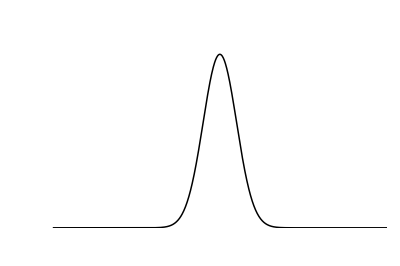

In [2]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.hist(norm(25, 1).rvs(10000), density=True, bins=50, color='#ffffff')
ax.plot(np.linspace(15, 35, 1000), norm(25, 1).pdf(np.linspace(15, 35, 1000)), color='#000000')
ax.set_xlim(15, 35)
ax.set_ylim(0, 0.5)
ax.set_xlabel('posterior of some parameter')
ax.set_ylabel('$p$')
#ax.set_facecolor('black')
ax.spines['bottom'].set_color('#ffffff')
ax.spines['top'].set_color('#ffffff') 
ax.spines['right'].set_color('#ffffff')
ax.spines['left'].set_color('#ffffff')
ax.tick_params(axis='x', colors='#ffffff')
ax.tick_params(axis='y', colors='#ffffff')
ax.set_xticks([15, 20, 25, 30, 35])
ax.set_yticks([0, 0.25, 0.5])
ax.yaxis.label.set_color('#ffffff')
ax.xaxis.label.set_color('#ffffff')
fig.savefig('prob.png', transparent=True, dpi=600)

In [3]:
import corner

In [4]:
a = norm(25, 1).rvs(10000) 
b = a * 10 + norm(10, 5).rvs(10000)

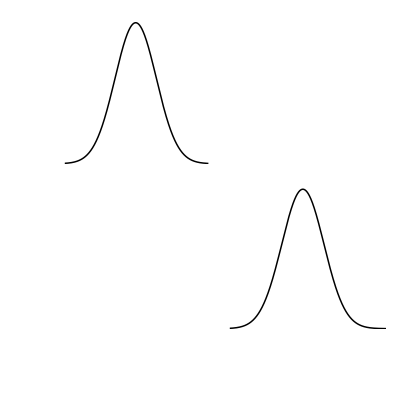

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
corner.corner(np.array([a, b]).T, fig=fig, bins=50, color='w', labels=['posterior a', 'posterior b'], hist_kwargs={'histtype':'stepfilled', 'density':True}, no_fill_contours=True)
for i in ax.flatten():
    i.spines['bottom'].set_color('#ffffff')
    i.spines['top'].set_color('#ffffff') 
    i.spines['right'].set_color('#ffffff')
    i.spines['left'].set_color('#ffffff')
    i.tick_params(axis='x', colors='#ffffff')
    i.tick_params(axis='y', colors='#ffffff')
    i.yaxis.label.set_color('#ffffff')
    i.xaxis.label.set_color('#ffffff')
ax[0, 0].plot(np.linspace(21.5, 28.5, 1000), norm(*norm.fit(a)).pdf(np.linspace(21.5, 28.5, 1000)), 'k')
ax[1, 1].plot(np.linspace(220, 305, 1000), norm(*norm.fit(b)).pdf(np.linspace(220, 305, 1000)), 'k')
fig.savefig('corner.png', transparent=True, dpi=600)

In [6]:
from uravu.relationship import Relationship
from uravu.utils import straight_line

x = np.linspace(1, 9, 5)
y = straight_line(x, 3, 1) + np.random.randn(5) * 0.7
dy = (4 - 3) * np.random.random_sample(5) + 3

r = Relationship(straight_line, x, y, ordinate_error=dy)
r2 = Relationship(straight_line, x, y, ordinate_error=dy)

In [7]:
m, c = [norm(loc=3, scale=0.25), norm(loc=0, scale=2)]

In [8]:
ll = [m, c]

In [9]:
def custom_prior():
    priors = []
    priors.append(m)
    priors.append(c)
    return priors

In [10]:
r.max_likelihood('mini')
r.mcmc()
r2.max_likelihood('mini')
r2.mcmc(prior_function=custom_prior)

100%|██████████| 1000/1000 [00:24<00:00, 41.62it/s]


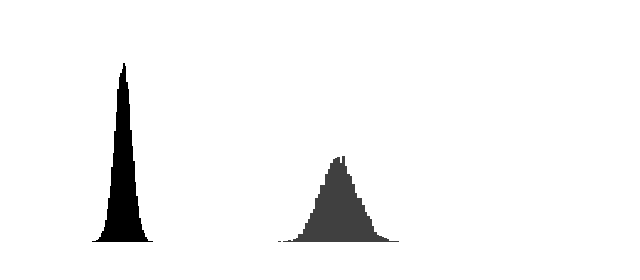

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 4))
l = ['m', 'm|\mathbf{D}', '\mathbf{D}|m']
ax[1].hist(r.variables[0].samples, color='#404040', density=True, bins=50)
ax[2].hist(r2.variables[0].samples, color='#ffffff', density=True, bins=50)
ax[0].hist(ll[0].rvs(20000), color='#000000', density=True, bins=50)
for i in [0, 1, 2]:
    ax[i].set_xlabel(f'$m$')
    ax[i].set_ylabel(f'$p({l[i]})$')
    #ax[i].set_facecolor('black')
    ax[i].spines['bottom'].set_color('#ffffff')
    ax[i].spines['top'].set_color('#ffffff') 
    ax[i].spines['right'].set_color('#ffffff')
    ax[i].spines['left'].set_color('#ffffff')
    ax[i].tick_params(axis='x', colors='#ffffff')
    ax[i].tick_params(axis='y', colors='#ffffff')
    ax[i].yaxis.label.set_color('#ffffff')
    ax[i].xaxis.label.set_color('#ffffff')
    ax[i].set_xlim(1, 5.5)
    ax[i].set_ylim(0, 2.1)
plt.tight_layout()
fig.savefig('postb.png', transparent=True, dpi=600)

In [12]:
import refnx
from refnx.dataset import ReflectDataset, Data1D
from refnx.analysis import Transform, CurveFitter, Objective, Model, Parameter
from refnx.reflect import SLD, Slab, ReflectModel, Structure

In [13]:
data = ReflectDataset('c_PLP0011859_q.txt')

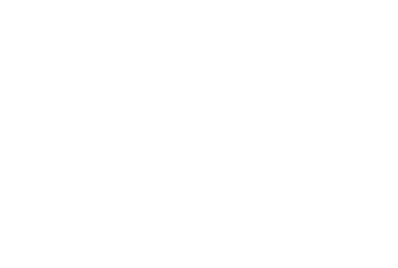

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.errorbar(data.x, data.y, data.y_err, marker='.', ls='', c='#ffffff')
ax.set_yscale('log')
ax.set_xlabel('$q_z$/Å$^{-1}$')
ax.set_ylabel('$R(q_z)$')
ax.spines['bottom'].set_color('#ffffff')
ax.spines['top'].set_color('#ffffff') 
ax.spines['right'].set_color('#ffffff')
ax.spines['left'].set_color('#ffffff')
ax.tick_params(axis='x', colors='#ffffff')
ax.tick_params(axis='y', colors='#ffffff')
ax.tick_params(axis='y', which='minor', colors='#ffffff')
ax.yaxis.label.set_color('#ffffff')
ax.xaxis.label.set_color('#ffffff')
fig.savefig('data_alone.png', transparent=True, dpi=600)

In [15]:
si = SLD(2.07, name='Si')
sio2 = SLD(3.47, name='SiO2')
film = SLD(2.0, name='film')
film0 = SLD(2.0, name='film')
d2o = SLD(6.36, name='d2o')

In [16]:
# first number is thickness, second number is roughness
# a native oxide layer
sio2_layer = sio2(30, 3)
sio2_layer0 = sio2(30, 3)

# the film of interest
film_layer = film(250, 3)
film_layer0 = film0(250, 3)

# layer for the solvent
d2o_layer = d2o(0, 3)
d2o_layer0 = d2o(0, 3)

In [17]:
sio2_layer.thick.setp(bounds=(15, 50), vary=True)
sio2_layer.rough.setp(bounds=(1, 15), vary=True)

film_layer.thick.setp(bounds=(200, 300), vary=True)
film_layer.sld.real.setp(bounds=(0.1, 3), vary=True)
film_layer.rough.setp(bounds=(1, 15), vary=True)

d2o_layer.rough.setp(vary=True, bounds=(1, 15))

In [18]:
structure = si | sio2_layer | film_layer | d2o_layer
structure0 = si | sio2_layer0 | film_layer0 | d2o_layer0

In [19]:
model = ReflectModel(structure, bkg=3e-6, dq=5.0)
model.scale.setp(bounds=(0.6, 1.2), vary=True)
model.bkg.setp(bounds=(1e-9, 9e-6), vary=True)

In [20]:
objective = Objective(model, data, transform=Transform('logY'))

In [21]:
fitter = CurveFitter(objective)
fitter.fit('differential_evolution');

50it [00:05,  9.60it/s]


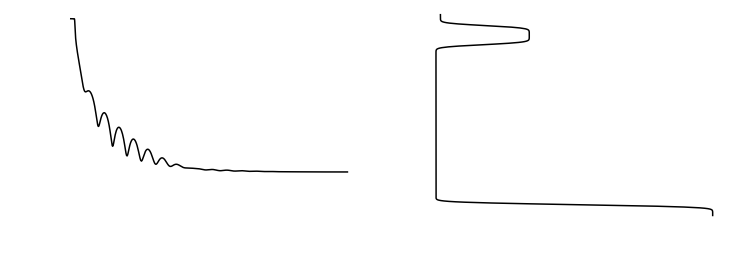

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
ax[0].errorbar(data.x, data.y, data.y_err, marker='.', ls='', c='#ffffff')
ax[0].plot(data.x, ReflectModel(structure0, bkg=3e-6, dq=5.0)(data.x), ls='-', c='#000000', zorder=9)
ax[0].set_yscale('log')
ax[0].set_xlabel('$q_z$/Å$^{-1}$')
ax[0].set_ylabel('$R(q)$')
#ax.set_facecolor('black')
ax[0].spines['bottom'].set_color('#ffffff')
ax[0].spines['top'].set_color('#ffffff') 
ax[0].spines['right'].set_color('#ffffff')
ax[0].spines['left'].set_color('#ffffff')
ax[0].tick_params(axis='x', colors='#ffffff')
ax[0].tick_params(axis='y', colors='#ffffff')
ax[0].tick_params(axis='y', which='minor', colors='#ffffff')
ax[0].yaxis.label.set_color('#ffffff')
ax[0].xaxis.label.set_color('#ffffff')
ax[1].plot(structure0.sld_profile()[1], structure0.sld_profile()[0], ls='-', c='#000000', zorder=9)
ax[1].set_ylim(310, -30)
ax[1].set_ylabel('$z$/Å')
ax[1].set_xlabel('SLD($z$)/Å$^{-2}$')
#ax.set_facecolor('black')
ax[1].spines['bottom'].set_color('#ffffff')
ax[1].spines['top'].set_color('#ffffff') 
ax[1].spines['right'].set_color('#ffffff')
ax[1].spines['left'].set_color('#ffffff')
ax[1].tick_params(axis='x', colors='#ffffff')
ax[1].tick_params(axis='y', colors='#ffffff')
ax[1].tick_params(axis='y', which='minor', colors='#ffffff')
ax[1].yaxis.label.set_color('#ffffff')
ax[1].xaxis.label.set_color('#ffffff')
fig.savefig('data.png', transparent=True, dpi=600)

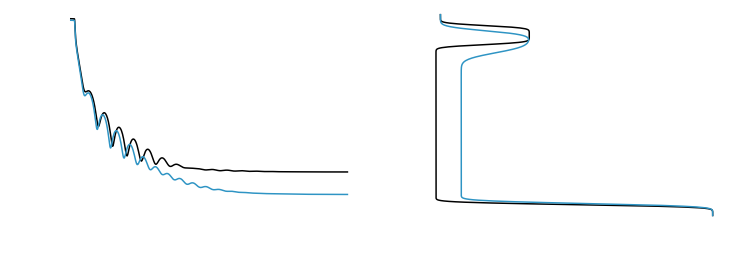

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
ax[0].errorbar(data.x, data.y, data.y_err, marker='.', ls='', c='#ffffff')
ax[0].plot(data.x, ReflectModel(structure0, bkg=3e-6, dq=5.0)(data.x), ls='-', c='#000000', zorder=9)
ax[0].plot(data.x, model(data.x), ls='-', c='#2e94c4', zorder=10)
ax[0].set_yscale('log')
ax[0].set_xlabel('$q_z$/Å$^{-1}$')
ax[0].set_ylabel('$R(q)$')
#ax.set_facecolor('black')
ax[0].spines['bottom'].set_color('#ffffff')
ax[0].spines['top'].set_color('#ffffff') 
ax[0].spines['right'].set_color('#ffffff')
ax[0].spines['left'].set_color('#ffffff')
ax[0].tick_params(axis='x', colors='#ffffff')
ax[0].tick_params(axis='y', colors='#ffffff')
ax[0].tick_params(axis='y', which='minor', colors='#ffffff')
ax[0].yaxis.label.set_color('#ffffff')
ax[0].xaxis.label.set_color('#ffffff')
ax[1].plot(structure0.sld_profile()[1], structure0.sld_profile()[0], ls='-', c='#000000', zorder=9)
ax[1].plot(structure.sld_profile()[1], structure0.sld_profile()[0], ls='-', c='#2e94c4', zorder=10)
ax[1].set_ylim(310, -30)
ax[1].set_ylabel('$z$/Å')
ax[1].set_xlabel('SLD($z$)/Å$^{-2}$')
#ax.set_facecolor('black')
ax[1].spines['bottom'].set_color('#ffffff')
ax[1].spines['top'].set_color('#ffffff') 
ax[1].spines['right'].set_color('#ffffff')
ax[1].spines['left'].set_color('#ffffff')
ax[1].tick_params(axis='x', colors='#ffffff')
ax[1].tick_params(axis='y', colors='#ffffff')
ax[1].tick_params(axis='y', which='minor', colors='#ffffff')
ax[1].yaxis.label.set_color('#ffffff')
ax[1].xaxis.label.set_color('#ffffff')
fig.savefig('data2.png', transparent=True, dpi=600)

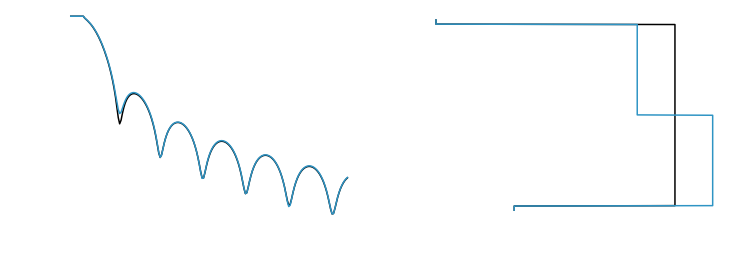

In [24]:
qvals = np.linspace(0,0.2,200)[1:]
sld1 = SLD(0, 0)
sld3 = SLD(2.074, 0)

layer1 = sld1(0, 0)
layer3 = sld3(0, 0)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
ax1 = ax[1]
ax2 = ax[0]
colors = ['#000000', '#2e94c4']
for i in [0,1]:
    sld20 = SLD(6.335 - i, 0)
    sld21 = SLD(6.335 + i, 0)
    layer20 = sld20(100, 0)
    layer21 = sld21(100, 0)
    structure = Structure(layer1 | layer20 | layer21 | layer3)
    z, rho = structure.sld_profile()

    ax1.plot(rho, z, color=colors[i])
    ax2.semilogy(qvals, ReflectModel(structure, dq=0.0).model(qvals), color=colors[i])
    
ax[0].spines['bottom'].set_color('#ffffff')
ax[0].spines['top'].set_color('#ffffff') 
ax[0].spines['right'].set_color('#ffffff')
ax[0].spines['left'].set_color('#ffffff')
ax[0].tick_params(axis='x', colors='#ffffff')
ax[0].tick_params(axis='y', colors='#ffffff')
ax[0].tick_params(axis='y', which='minor', colors='#ffffff')
ax[0].yaxis.label.set_color('#ffffff')
ax[0].xaxis.label.set_color('#ffffff')
ax[1].spines['bottom'].set_color('#ffffff')
ax[1].spines['top'].set_color('#ffffff') 
ax[1].spines['right'].set_color('#ffffff')
ax[1].spines['left'].set_color('#ffffff')
ax[1].tick_params(axis='x', colors='#ffffff')
ax[1].tick_params(axis='y', colors='#ffffff')
ax[1].tick_params(axis='y', which='minor', colors='#ffffff')
ax[1].yaxis.label.set_color('#ffffff')
ax[1].xaxis.label.set_color('#ffffff')

ax1.set_xlabel(r'$z$/Å')
ax1.set_ylabel(r'$\rho(z)$/Å$^{-2}$')
ax1.set_ylim(220, -20)

ax2.set_xlabel(r'$q_z$/Å')
ax2.set_ylabel(r'$R(q_z)$')
fig.savefig('phase.png', transparent=True, dpi=600)

In [25]:
import lipids_at_airdes.src.tools.helper as helper
import lipids_at_airdes.src.models.mol_vol as mv
from refnx.analysis import GlobalObjective

In [26]:
# Relative directory locations
data_dir = 'lipids_at_airdes/data/processed/{}_'.format('dmpc')
figures_dir = 'lipids_at_airdes//reports/figures/'
analysis_dir = 'lipids_at_airdes//output/'
# Reading datasets into refnx format
sp1 = '20'
sp2 = '25'
sp3 = '30'
sp4 = '40'
sps = [sp1, sp2, sp3, sp4]
dataset1 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp1)), 0.6)
dataset2 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp2)), 0.6)
dataset3 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp3)), 0.6)
dataset4 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp4)), 0.6)

datasets = [dataset1, dataset2, dataset3, dataset4]

lipid='dmpc'
length=13

if lipid == 'dmpg':
    head = {'C': 8, 'H': 12, 'O': 10, 'Na': 1, 'P': 1}
else:
    head = {'C': 10, 'H': 18, 'O': 8, 'N': 1, 'P': 1}
tail = {'C': length * 2, 'H': length * 4 + 2}

head_sl = mv.get_scattering_length(head)
tail_sl = mv.get_scattering_length(tail)

thick_heads = 11.057
if lipid == 'dlpc':
    vols = [330., 667.]
if lipid == 'dmpg':
    vols = [330., 779.]
if lipid == 'dmpc':
    vols = [330., 779.]
if lipid == 'dppc':
    vols = [330., 891.]

tail_length = 1.54 + 1.265 * length

lipid1 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}1'.format(lipid))
lipid2 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}2'.format(lipid))
lipid3 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}3'.format(lipid))
lipid4 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}4'.format(lipid))

air = SLD(0, 'air')
des = SLD(10.8, 'des')

structure_lipid1 = air(0, 0) | lipid1 | des(0, 3.3)
structure_lipid2 = air(0, 0) | lipid2 | des(0, 3.3)
structure_lipid3 = air(0, 0) | lipid3 | des(0, 3.3)
structure_lipid4 = air(0, 0) | lipid4 | des(0, 3.3)

lipid1.head_mol_vol.setp(vary=True, bounds=(vols[0]*0.8, vols[0]*1.2))
lipid1.tail_mol_vol.setp(vary=True, bounds=(vols[1]*0.8, vols[1]*1.2))
lipid1.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid1.rough_head_tail.constraint = structure_lipid1[-1].rough
lipid1.rough_preceding_mono.constraint = structure_lipid1[-1].rough
lipid1.phih.constraint = 1 - (lipid1.head_mol_vol /  lipid1.tail_mol_vol) * (
    lipid1.thick_tails / lipid1.thick_heads)
lipid1.thick_heads.setp(vary=True, bounds=(6, 20))
structure_lipid1[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipid2.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid2.rough_head_tail.constraint = structure_lipid2[-1].rough
lipid2.rough_preceding_mono.constraint = structure_lipid2[-1].rough
lipid2.thick_heads.setp(vary=True, bounds=(6, 20))
lipid2.phih.constraint = 1 - (lipid2.head_mol_vol / lipid2.tail_mol_vol) * (
    lipid2.thick_tails / lipid2.thick_heads)
structure_lipid2[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipid3.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid3.rough_head_tail.constraint = structure_lipid3[-1].rough
lipid3.rough_preceding_mono.constraint = structure_lipid3[-1].rough
lipid3.thick_heads.setp(vary=True, bounds=(6, 20))
lipid3.phih.constraint = 1 - (lipid3.head_mol_vol / lipid3.tail_mol_vol) * (
    lipid3.thick_tails / lipid3.thick_heads)
structure_lipid3[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipid4.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid4.rough_head_tail.constraint = structure_lipid4[-1].rough
lipid4.rough_preceding_mono.constraint = structure_lipid4[-1].rough
lipid4.thick_heads.setp(vary=True, bounds=(6, 20))
lipid4.phih.constraint = 1 - (lipid4.head_mol_vol / lipid4.tail_mol_vol) * (
    lipid4.thick_tails / lipid4.thick_heads)
structure_lipid4[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipids = [lipid1, lipid2, lipid3, lipid4]
structures = [structure_lipid1, structure_lipid2, structure_lipid3, structure_lipid4]
lipids = mv.set_constraints(lipids, vary_tails=True)

model_lipid1 = ReflectModel(structure_lipid1)
model_lipid1.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid1.bkg.setp(dataset1.y[-1], vary=False)

model_lipid2 = ReflectModel(structure_lipid2)
model_lipid2.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid2.bkg.setp(dataset2.y[-1], vary=False)

model_lipid3 = ReflectModel(structure_lipid3)
model_lipid3.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid3.bkg.setp(dataset3.y[-1], vary=False)

model_lipid4 = ReflectModel(structure_lipid4)
model_lipid4.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid4.bkg.setp(dataset4.y[-1], vary=False)

models = [model_lipid1, model_lipid2, model_lipid3, model_lipid4]

objective1 = Objective(model_lipid1, dataset1, transform=Transform('YX4'))
objective2 = Objective(model_lipid2, dataset2, transform=Transform('YX4'))
objective3 = Objective(model_lipid3, dataset3, transform=Transform('YX4'))
objective4 = Objective(model_lipid4, dataset4, transform=Transform('YX4'))

global_objective = GlobalObjective([objective1, objective2, objective3, objective4])

In [27]:
chain = refnx.analysis.load_chain('{}/{}/chain.txt'.format(analysis_dir, lipid))

processed_chain = refnx.analysis.process_chain(global_objective, chain)

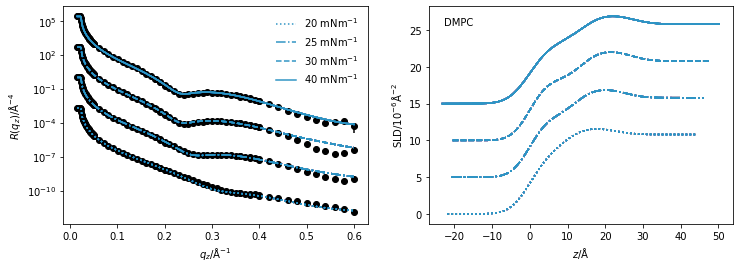

In [28]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lines = [':', '-.', '--', '-']

for i, dataset in enumerate(datasets):
    choose = global_objective.pgen(ngen=100)
    ax1 = ax[0]
    ax2 = ax[1]
    ax1.errorbar(dataset.x, dataset.y * 500**(i-1), 
                 yerr=dataset.y_err * 500**(i-1), 
                 linestyle='', marker='o', color='#000000')
    for pvec in choose:
        global_objective.setp(pvec)
        ax1.plot(dataset.x, models[i](dataset.x, x_err=dataset.x_err) * 500**(i-1), 
                 color='#2e94c4', ls=lines[i], alpha=0.1, zorder=10)
        zs, sld = structures[i].sld_profile()
        ax2.plot(zs, sld + i*5, color='#2e94c4', ls=lines[i], alpha=0.1)
    ax1.plot(dataset.x, models[i](dataset.x, x_err=dataset.x_err)* 500**(i-1), 
            color='#2e94c4', ls=lines[i], label = sps[i] + ' mNm$^{-1}$', zorder=10)
    ax1.set_ylabel(r'$R(q_z)$/Å$^{-4}$')
    ax1.set_yscale('log')
    ax1.set_xlabel(r'$q_z$/Å$^{-1}$')
    ax2.set_xlabel(r'$z$/Å')
    ax2.set_ylabel(r'SLD/$10^{-6}$Å$^{-2}$')
ax1.legend(frameon=False)
for i in [0, 1]:
    ax[i].spines['bottom'].set_color('#000000')
    ax[i].spines['top'].set_color('#000000') 
    ax[i].spines['right'].set_color('#000000')
    ax[i].spines['left'].set_color('#000000')
    ax[i].tick_params(axis='x', colors='#000000')
    ax[i].tick_params(axis='y', colors='#000000')
    ax[i].yaxis.label.set_color('#000000')
    ax[i].xaxis.label.set_color('#000000')
ax[1].text(0.05, 0.95, 'DMPC', horizontalalignment='left',
        verticalalignment='top',
        transform=ax[1].transAxes, color='#000000')
fig.savefig('dmpc.png', transparent=True, dpi=600)

In [29]:
tail1 = processed_chain[2].chain
tail2 = processed_chain[7].chain
tail3 = processed_chain[10].chain
tail4 = processed_chain[13].chain

solh1 = 1 - (processed_chain[4].chain / processed_chain[3].chain) * (
    tail1 / processed_chain[1].chain)
solh2 = 1 - (processed_chain[4].chain / processed_chain[3].chain) * (
    tail2 / processed_chain[1].chain)
solh3 = 1 - (processed_chain[4].chain / processed_chain[3].chain) * (
    tail3 / processed_chain[1].chain)
solh4 = 1 - (processed_chain[4].chain / processed_chain[3].chain) * (
    tail4 / processed_chain[1].chain)

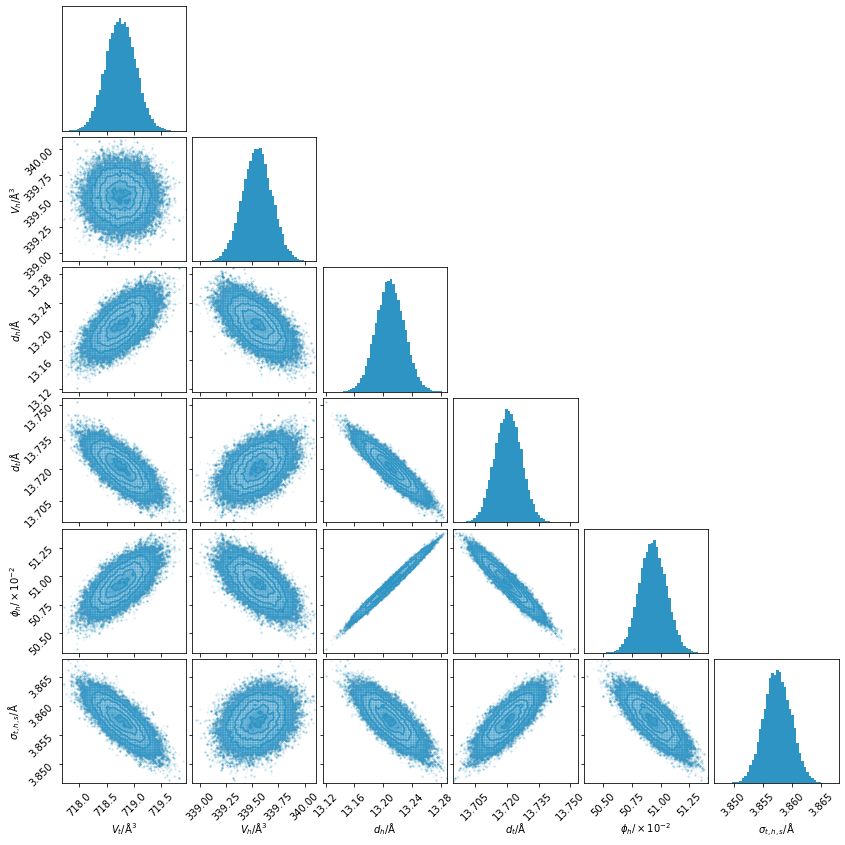

In [30]:
label=['$V_t$/Å$^3$', '$V_h$/Å$^3$', '$d_h$/Å', '$d_t$/Å', r'$ϕ_h/\times10^{-2}$', '$σ_{t,h,s}$/Å']

new_flat = np.zeros((processed_chain[0].chain.size, 6))

new_flat[:, 0] = list(processed_chain[3].chain.flatten())
new_flat[:, 1] = list(processed_chain[4].chain.flatten())
new_flat[:, 3] = list(processed_chain[10].chain.flatten())
new_flat[:, 5] = list(processed_chain[11].chain.flatten())
new_flat[:, 2] = list(processed_chain[1].chain.flatten())
new_flat[:, 4] = list(solh3.flatten() * 100)

fig, ax = plt.subplots(6, 6, figsize=(12, 12))
corner.corner(new_flat, fig=fig, bins=50, color='#2e94c4', labels=label, hist_kwargs={'histtype':'stepfilled', 'density':True}, no_fill_contours=True)
for i in ax.flatten():
    i.spines['bottom'].set_color('#000000')
    i.spines['top'].set_color('#000000') 
    i.spines['right'].set_color('#000000')
    i.spines['left'].set_color('#000000')
    i.tick_params(axis='x', colors='#000000')
    i.tick_params(axis='y', colors='#000000')
    i.yaxis.label.set_color('#000000')
    i.xaxis.label.set_color('#000000')
fig.savefig('dmpc3_all_corner.png', transparent=True, dpi=600)

In [31]:
# Relative directory locations
data_dir = 'lipids_at_airdes/data/processed/{}_'.format('dmpg')
figures_dir = 'lipids_at_airdes//reports/figures/'
analysis_dir = 'lipids_at_airdes//output/'
# Reading datasets into refnx format
sp1 = '15'
sp2 = '20'
sp3 = '25'
sp4 = '30'
sps = [sp1, sp2, sp3, sp4]
dataset1 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp1)), 0.6)
dataset2 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp2)), 0.6)
dataset3 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp3)), 0.6)
dataset4 = helper.data_cutoff(ReflectDataset('{}xrr_sp_{}.dat'.format(data_dir, sp4)), 0.6)

datasets = [dataset1, dataset2, dataset3, dataset4]

lipid='dmpg'
length=13

if lipid == 'dmpg':
    head = {'C': 8, 'H': 12, 'O': 10, 'Na': 1, 'P': 1}
else:
    head = {'C': 10, 'H': 18, 'O': 8, 'N': 1, 'P': 1}
tail = {'C': length * 2, 'H': length * 4 + 2}

head_sl = mv.get_scattering_length(head)
tail_sl = mv.get_scattering_length(tail)

thick_heads = 11.057
if lipid == 'dlpc':
    vols = [330., 667.]
if lipid == 'dmpg':
    vols = [330., 779.]
if lipid == 'dmpc':
    vols = [330., 779.]
if lipid == 'dppc':
    vols = [330., 891.]

tail_length = 1.54 + 1.265 * length

lipid1 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}1'.format(lipid))
lipid2 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}2'.format(lipid))
lipid3 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}3'.format(lipid))
lipid4 = mv.VolMono(head_sl, thick_heads, tail_sl, tail_length, vols, 
                    reverse_monolayer=True, name='{}4'.format(lipid))

air = SLD(0, 'air')
des = SLD(10.8, 'des')

structure_lipid1 = air(0, 0) | lipid1 | des(0, 3.3)
structure_lipid2 = air(0, 0) | lipid2 | des(0, 3.3)
structure_lipid3 = air(0, 0) | lipid3 | des(0, 3.3)
structure_lipid4 = air(0, 0) | lipid4 | des(0, 3.3)

lipid1.head_mol_vol.setp(vary=True, bounds=(vols[0]*0.8, vols[0]*1.2))
lipid1.tail_mol_vol.setp(vary=True, bounds=(vols[1]*0.8, vols[1]*1.2))
lipid1.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid1.rough_head_tail.constraint = structure_lipid1[-1].rough
lipid1.rough_preceding_mono.constraint = structure_lipid1[-1].rough
lipid1.phih.constraint = 1 - (lipid1.head_mol_vol /  lipid1.tail_mol_vol) * (
    lipid1.thick_tails / lipid1.thick_heads)
lipid1.thick_heads.setp(vary=True, bounds=(6, 20))
structure_lipid1[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipid2.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid2.rough_head_tail.constraint = structure_lipid2[-1].rough
lipid2.rough_preceding_mono.constraint = structure_lipid2[-1].rough
lipid2.thick_heads.setp(vary=True, bounds=(6, 20))
lipid2.phih.constraint = 1 - (lipid2.head_mol_vol / lipid2.tail_mol_vol) * (
    lipid2.thick_tails / lipid2.thick_heads)
structure_lipid2[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipid3.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid3.rough_head_tail.constraint = structure_lipid3[-1].rough
lipid3.rough_preceding_mono.constraint = structure_lipid3[-1].rough
lipid3.thick_heads.setp(vary=True, bounds=(6, 20))
lipid3.phih.constraint = 1 - (lipid3.head_mol_vol / lipid3.tail_mol_vol) * (
    lipid3.thick_tails / lipid3.thick_heads)
structure_lipid3[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipid4.thick_tails.setp(vary=True, bounds=(5, tail_length))
lipid4.rough_head_tail.constraint = structure_lipid4[-1].rough
lipid4.rough_preceding_mono.constraint = structure_lipid4[-1].rough
lipid4.thick_heads.setp(vary=True, bounds=(6, 20))
lipid4.phih.constraint = 1 - (lipid4.head_mol_vol / lipid4.tail_mol_vol) * (
    lipid4.thick_tails / lipid4.thick_heads)
structure_lipid4[-1].rough.setp(vary=True, bounds=(2.5, 6))

lipids = [lipid1, lipid2, lipid3, lipid4]
structures = [structure_lipid1, structure_lipid2, structure_lipid3, structure_lipid4]
lipids = mv.set_constraints(lipids, vary_tails=True)

model_lipid1 = ReflectModel(structure_lipid1)
model_lipid1.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid1.bkg.setp(dataset1.y[-1], vary=False)

model_lipid2 = ReflectModel(structure_lipid2)
model_lipid2.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid2.bkg.setp(dataset2.y[-1], vary=False)

model_lipid3 = ReflectModel(structure_lipid3)
model_lipid3.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid3.bkg.setp(dataset3.y[-1], vary=False)

model_lipid4 = ReflectModel(structure_lipid4)
model_lipid4.scale.setp(vary=True, bounds=(0.005, 10))
model_lipid4.bkg.setp(dataset4.y[-1], vary=False)

models = [model_lipid1, model_lipid2, model_lipid3, model_lipid4]

objective1 = Objective(model_lipid1, dataset1, transform=Transform('YX4'))
objective2 = Objective(model_lipid2, dataset2, transform=Transform('YX4'))
objective3 = Objective(model_lipid3, dataset3, transform=Transform('YX4'))
objective4 = Objective(model_lipid4, dataset4, transform=Transform('YX4'))

global_objective = GlobalObjective([objective1, objective2, objective3, objective4])

In [32]:
chain = refnx.analysis.load_chain('{}/{}/chain.txt'.format(analysis_dir, lipid))

processed_chain = refnx.analysis.process_chain(global_objective, chain)

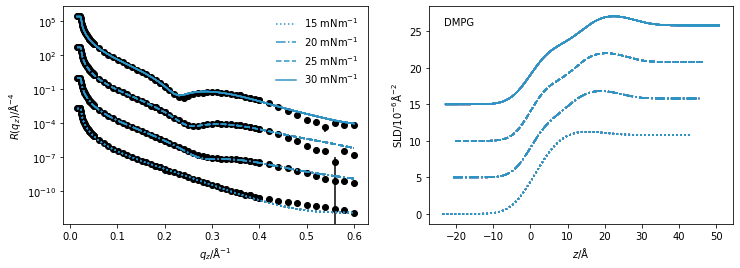

In [33]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lines = [':', '-.', '--', '-']

for i, dataset in enumerate(datasets):
    choose = global_objective.pgen(ngen=100)
    ax1 = ax[0]
    ax2 = ax[1]
    ax1.errorbar(dataset.x, dataset.y * 500**(i-1), 
                 yerr=dataset.y_err * 500**(i-1), 
                 linestyle='', marker='o', color='#000000')
    for pvec in choose:
        global_objective.setp(pvec)
        ax1.plot(dataset.x, models[i](dataset.x, x_err=dataset.x_err) * 500**(i-1), 
                 color='#2e94c4', ls=lines[i], alpha=0.1, zorder=10)
        zs, sld = structures[i].sld_profile()
        ax2.plot(zs, sld + i*5, color='#2e94c4', ls=lines[i], alpha=0.1)
    ax1.plot(dataset.x, models[i](dataset.x, x_err=dataset.x_err)* 500**(i-1), 
            color='#2e94c4', ls=lines[i], label = sps[i] + ' mNm$^{-1}$', zorder=10)
    ax1.set_ylabel(r'$R(q_z)$/Å$^{-4}$')
    ax1.set_yscale('log')
    ax1.set_xlabel(r'$q_z$/Å$^{-1}$')
    ax2.set_xlabel(r'$z$/Å')
    ax2.set_ylabel(r'SLD/$10^{-6}$Å$^{-2}$')
ax1.legend(frameon=False)
for i in [0, 1]:
    ax[i].spines['bottom'].set_color('#000000')
    ax[i].spines['top'].set_color('#000000') 
    ax[i].spines['right'].set_color('#000000')
    ax[i].spines['left'].set_color('#000000')
    ax[i].tick_params(axis='x', colors='#000000')
    ax[i].tick_params(axis='y', colors='#000000')
    ax[i].yaxis.label.set_color('#000000')
    ax[i].xaxis.label.set_color('#000000')
ax[1].text(0.05, 0.95, 'DMPG', horizontalalignment='left',
        verticalalignment='top',
        transform=ax[1].transAxes, color='#000000')
fig.savefig('dmpg.png', transparent=True, dpi=600)

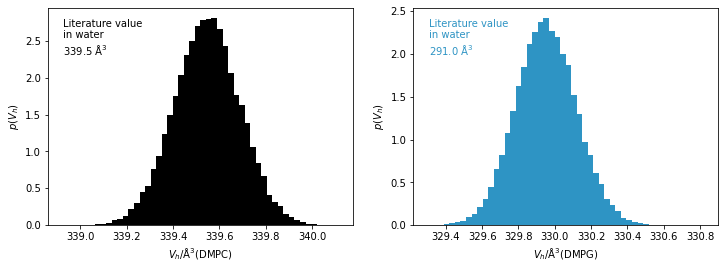

In [34]:
pc = np.loadtxt('dmpc_vh.txt')
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
ax[0].hist(pc, color='#000000', density=True, bins=50)
ax[0].set_ylabel('$p(V_h)$')
ax[0].set_xlabel('$V_h$/Å$^3$(DMPC)')
ax[0].spines['bottom'].set_color('#000000')
ax[0].spines['top'].set_color('#000000') 
ax[0].spines['right'].set_color('#000000')
ax[0].spines['left'].set_color('#000000')
ax[0].tick_params(axis='x', colors='#000000')
ax[0].tick_params(axis='y', colors='#000000')
ax[0].yaxis.label.set_color('#000000')
ax[0].xaxis.label.set_color('#000000')
ax[0].text(0.05, 0.95, 'Literature value\nin water\n339.5 Å$^3$', horizontalalignment='left',
        verticalalignment='top',
        transform=ax[0].transAxes)
pg = np.loadtxt('dmpg_vh.txt')
ax[1].hist(pg, color='#2e94c4', density=True, bins=50)
ax[1].set_ylabel('$p(V_h)$')
ax[1].set_xlabel('$V_h$/Å$^3$(DMPG)')
ax[1].spines['bottom'].set_color('#000000')
ax[1].spines['top'].set_color('#000000') 
ax[1].spines['right'].set_color('#000000')
ax[1].spines['left'].set_color('#000000')
ax[1].tick_params(axis='x', colors='#000000')
ax[1].tick_params(axis='y', colors='#000000')
ax[1].yaxis.label.set_color('#000000')
ax[1].xaxis.label.set_color('#000000')
ax[1].text(0.05, 0.95, 'Literature value\nin water\n291.0 Å$^3$', horizontalalignment='left',
        verticalalignment='top',
        transform=ax[1].transAxes, color='#2e94c4')
fig.savefig('heads.png', transparent=True, dpi=600)

In [35]:
import itertools

In [36]:
variables = [
    "th",
    "mvh",
    "tt", 
    "phit",
    "mvt",
    "rough", 
]

VARIABLES = []
for i in range(len(variables)):
    for j in itertools.combinations(variables, i + 1):
        VARIABLES.append('_'.join(j))
        
variables = [
    "$d_h$",
    "$V_h$",
    "$d_t$", 
    "$\phi_t$",
    "$V_t$",
    "$\sigma$", 
]

VARIABLES_F = []
for i in range(len(variables)):
    for j in itertools.combinations(variables, i + 1):
        VARIABLES_F.append('/'.join(j))

In [37]:
values = np.zeros((len(VARIABLES), 2))
for i, ff in enumerate(VARIABLES):
    f = open('./model_select/paper/' + ff + '_ev.txt', 'r')
    jj = f.read()
    f.close()
    values[i, 0] = float(jj[5:-7])
    values[i, 1] = float(jj[-4:-1])

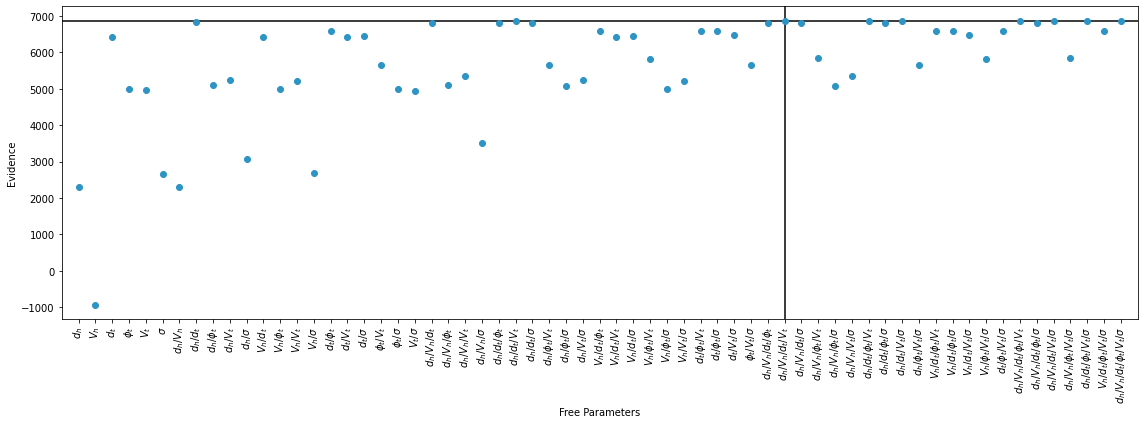

In [38]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16,6))
ax.errorbar(range(len(values)), values[:, 0], values[:, 1], marker='o', ls='', c='#2e94c4')
ax.axvline(range(len(values))[np.argmax(values[:, 0])], c='#000000')
ax.axhline(np.max(values[:, 0]), c='#000000')
ax.set_xticks(range(len(values)))
ax.set_xticklabels(VARIABLES_F)
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlim(-1, len(VARIABLES))
ax.set_ylabel('Evidence')
ax.set_xlabel('Free Parameters')
ax.spines['bottom'].set_color('#000000')
ax.spines['top'].set_color('#000000') 
ax.spines['right'].set_color('#000000')
ax.spines['left'].set_color('#000000')
ax.tick_params(axis='x', colors='#000000')
ax.tick_params(axis='y', colors='#000000')
ax.yaxis.label.set_color('#000000')
ax.xaxis.label.set_color('#000000')
plt.tight_layout()
fig.savefig('evidence.png', transparent=True, dpi=600)

In [39]:
variables = [
    "th",
    "mvh",
    "tt", 
    "phit",
    "mvt",
    "rough", 
]

VARIABLES = []
for i in range(len(variables)):
    V = []
    for j in itertools.combinations(variables, i + 1):
        V.append('_'.join(j))
    VARIABLES.append(V)
        
variables = [
    "$d_h$",
    "$V_h$",
    "$d_t$", 
    "$\phi_t$",
    "$V_t$",
    "$\sigma$", 
]

VARIABLES_F = []
for i in range(len(variables)):
    V = []
    for j in itertools.combinations(variables, i + 1):
        V.append('/'.join(j))
    VARIABLES_F.append(V)

In [40]:
values = np.zeros((6, 2))
labels = ['a'] * 6
for i, ff in enumerate(VARIABLES):
    for j, kk in enumerate(ff):
        f = open('./model_select/paper/' + kk + '_ev.txt', 'r')
        jj = f.read()
        f.close()
        if float(jj[5:-7]) > values[i, 0]:
            values[i, 0] = float(jj[5:-7])
            values[i, 1] = float(jj[-4:-1])
            labels[i] = VARIABLES_F[i][j]

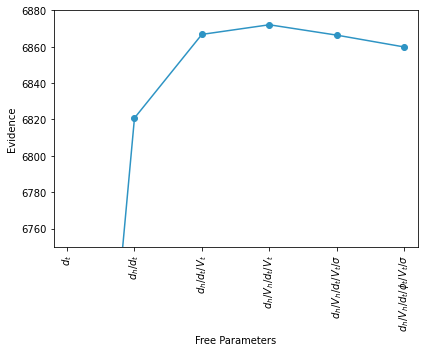

In [41]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6,5))
ax.errorbar(range(len(values)), values[:, 0], values[:, 1], marker='o', ls='-', c='#2e94c4')
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels)
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlim(-0.2, len(VARIABLES)-0.8)
ax.set_ylim(6750, 6880)
ax.set_ylabel('Evidence')
ax.set_xlabel('Free Parameters')
ax.spines['bottom'].set_color('#000000')
ax.spines['top'].set_color('#000000') 
ax.spines['right'].set_color('#000000')
ax.spines['left'].set_color('#000000')
ax.tick_params(axis='x', colors='#000000')
ax.tick_params(axis='y', colors='#000000')
ax.yaxis.label.set_color('#000000')
ax.xaxis.label.set_color('#000000')
plt.tight_layout()
fig.savefig('best_per.png', transparent=True, dpi=600)